In [ ]:
!pip install transformers

                                                   text  \
0     According to Gran , the company has no plans t...   
1     With the new production plant the company woul...   
2     For the last quarter of 2010 , Componenta 's n...   
3     In the third quarter of 2010 , net sales incre...   
4     Operating profit rose to EUR 13.1 mn from EUR ...   
...                                                 ...   
3448  Operating result for the 12-month period decre...   
3449  HELSINKI Thomson Financial - Shares in Cargote...   
3450  LONDON MarketWatch -- Share prices ended lower...   
3451  Operating profit fell to EUR 35.4 mn from EUR ...   
3452  Sales in Finland decreased by 10.5 % in Januar...   

                                               sentence sentiment  
0     According to Gran , the company has no plans t...   neutral  
1     With the new production plant the company woul...  positive  
2     For the last quarter of 2010 , Componenta 's n...  positive  
3     In the third 

<Axes: xlabel='count', ylabel='sentiment'>

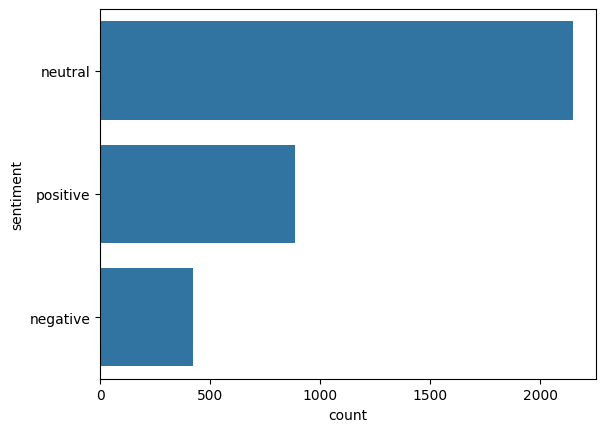

In [ ]:
import transformers
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import pandas as pd

# get data from the 75% dataset

# for 100% agreement dataset, use Sentences_AllAgree.txt
# for 75% agreement dataset, use Sentences_75Agree.txt

file_path = "Sentences_75Agree.txt"

with open(file_path, "r", errors="replace") as f:
    data = f.readlines()

df = pd.DataFrame(data, columns=["text"])

# split the text into -> [sentence, sentiment]
df['text'] = df['text'].str.strip()
df[['sentence', 'sentiment']] = df['text'].str.rsplit('@', n=1, expand=True)

print(df)
sns.countplot(df.sentiment)

100%|██████████| 3453/3453 [00:00<00:00, 6226.32it/s]
<ipython-input-30-ceb67a5c5f91>:20: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(token_lens)


<Axes: ylabel='Density'>

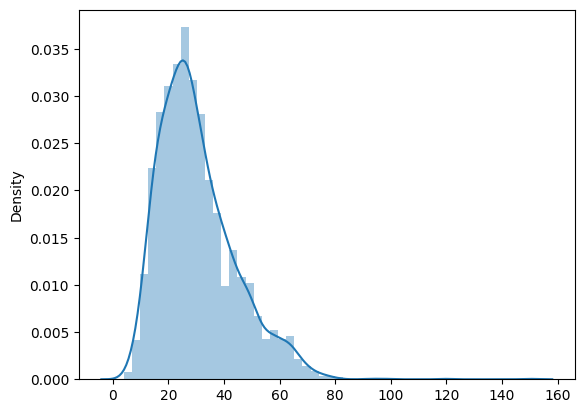

In [ ]:
from tqdm import tqdm
from transformers import AutoTokenizer

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# load pre-trained BERT tokenizer
# PRE_TRAINED_MODEL_NAME = 'bert-base-cased'
# tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

PRE_TRAINED_MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
tokenizer = AutoTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)


# use distplot to see sizes of sentences (in words)
token_lens = []
for sen in tqdm(df.sentence):
  tokens = tokenizer.encode(sen, max_length=512)
  token_lens.append(len(tokens))

sns.distplot(token_lens)

In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd

# split the data into 80% training, 10% validation, and 10% test
# and set the seed for a consistent testing environment
SEED = 1234

class SentimentDataset(Dataset):
    def __init__(self, sentences, sentiments, tokenizer, max_len):
        self.sentences = sentences
        self.sentiments = sentiments
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.label_dict = {'negative': 0, 'positive': 1, 'neutral': 2}

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, item):
        sentence = str(self.sentences[item])
        sentiment = self.sentiments[item]
        encoding = self.tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'sentence': sentence,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(self.label_dict[sentiment], dtype=torch.long)
        }

MAX_LEN = 160
dataset = SentimentDataset(
    sentences=df['sentence'].to_numpy(),
    sentiments=df['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

train_size = int(0.8 * df.shape[0])
validate_size = int(0.1 * df.shape[0])
test_size = df.shape[0] - train_size - validate_size

train_data, validate_data, test_data = random_split(
    dataset,
    [train_size, validate_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)


batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
validate_loader = DataLoader(validate_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [ ]:
# this block here was just to help me confirm that there were different
# sentiments within each split (train, validate, test) to help with early debugging

def get_sentiments(data_split):
    sentiments = []
    for item in data_split:
        sentiments.append(item['targets'].item())
    return sentiments

train_sentiments = get_sentiments(train_data)
validate_sentiments = get_sentiments(validate_data)
test_sentiments = get_sentiments(test_data)

print("Train Sentiments:", train_sentiments)
print("Validation Sentiments:", validate_sentiments)
print("Test Sentiments:", test_sentiments)

Train Sentiments: [0, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 0, 1, 2, 0, 0, 2, 2, 1, 2, 2, 0, 0, 2, 1, 0, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 2, 0, 1, 1, 2, 2, 2, 1, 0, 2, 2, 1, 2, 1, 2, 0, 2, 1, 1, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 0, 1, 2, 0, 0, 2, 2, 1, 1, 2, 2, 2, 1, 1, 0, 1, 1, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 1, 0, 2, 1, 2, 1, 2, 0, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 2, 2, 0, 2, 1, 1, 1, 0, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 2, 1, 1, 0, 0, 1, 0, 0, 2, 2, 1, 2, 0, 1, 2, 2, 2, 2, 1, 0, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 1, 2, 0, 2, 2, 2, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 0, 2, 2, 0, 1, 2, 2, 2, 0, 2, 2, 1, 1, 1, 2, 1, 

Creating a fine-tuned BERT model

In [ ]:
# uncomment if using original BERT model

# bert_model = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)

# class SentimentClassifier(nn.Module):
#     def __init__(self, n_classes):
#         super(SentimentClassifier, self).__init__()
#         self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
#         self.drop = nn.Dropout(p=0.4)
#         #self.out = nn.Linear(self.bert.config.hidden_size, n_classes)
#         self.out1 = nn.Linear(self.bert.config.hidden_size, 128)
#         self.drop1 = nn.Dropout(p=0.4)
#         self.relu = nn.ReLU()
#         self.out = nn.Linear(128, n_classes)

#     def forward(self, input_ids, attention_mask):
#         outputs = self.bert(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         pooled_output = outputs.pooler_output  # Correctly extract the pooled output
#         output = self.drop(pooled_output)
#         output = self.out1(output)
#         output = self.relu(output)
#         output = self.drop1(output)
#         return self.out(output)

# using distilbert model
from transformers import DistilBertModel

# Stanford Sentiment Treebank (SST-2) dataset, which is designed for binary classification (positive vs. negative).
PRE_TRAINED_MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
model = DistilBertModel.from_pretrained(PRE_TRAINED_MODEL_NAME, force_download=True)
model.classifier = torch.nn.Linear(model.config.hidden_size, 3)

class SentimentClassifier(nn.Module):
    def __init__(self, n_classes):
        super(SentimentClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
        self.drop = nn.Dropout(p=0.4)
        self.out1 = nn.Linear(self.bert.config.hidden_size, 128)
        self.drop1 = nn.Dropout(p=0.4)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled_output = outputs.last_hidden_state[:, 0]
        output = self.drop(pooled_output)
        output = self.out1(output)
        output = self.relu(output)
        output = self.drop1(output)
        return self.out(output)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
def train_epoch(model,data_loader,loss_fn,optimizer,device,scheduler,n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0

    for d in data_loader:
        input_ids = d['input_ids'].to(device)
        attention_mask = d['attention_mask'].to(device)
        targets = d['targets'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs,targets)

        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return correct_predictions.double() / n_examples, np.mean(losses)


def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)
            correct_predictions += torch.sum(preds == targets)
            losses.append(loss.item())

    return correct_predictions.double() / n_examples, np.mean(losses)


In [ ]:
print(len(train_data))
print(len(validate_data))
print(len(test_data))

1811
226
227


In [ ]:
# testing to see if a different loss function will work better

from torch.nn import functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return focal_loss.mean()

In [ ]:
from collections import defaultdict
import time

history = defaultdict(list)
best_accuracy = 0

class_name = ['negative','positive', 'neutral']

model = SentimentClassifier(len(class_name))
model = model.to(device)

# num epochs and learning rate
EPOCHS = 5
alpha = 2e-5 # 3e-5

optimizer = AdamW(model.parameters(), alpha, correct_bias=False)
# optimizer = torch.optim.RMSprop(model.parameters(), lr=alpha)


total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
#class_weights = torch.FloatTensor(class_weights).to(device)
#weight=class_weights
# loss_fn = FocalLoss(gamma=2.0, alpha=0.25).to(device)
loss_fn = nn.CrossEntropyLoss().to(device)

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

for epoch in range(EPOCHS):

    start_time = time.time()

    train_acc, train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device, scheduler, len(train_data))
    val_acc, val_loss = eval_model(model, validate_loader, loss_fn, device, len(validate_data))

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {val_loss:.3f} |  Val. Acc: {val_acc*100:.2f}%')

    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_model_state.bin')
        best_accuracy = val_acc

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
model.load_state_dict(torch.load('best_model_state_75.bin'))
test_acc, test_loss = eval_model(model, test_loader, loss_fn, device, len(test_data))

print(test_acc.item())

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

<ipython-input-28-a1d11cca6bb5>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_state_75.bin'))


0.9911894273127754
Test Loss: 0.044 | Test Acc: 99.12%


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix

def get_predictions(model, data_loader):
    model = model.eval()
    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:
            texts = d["sentence"]
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            _, preds = torch.max(outputs, dim=1)
            review_texts.extend(texts)
            predictions.extend(preds)
            prediction_probs.extend(outputs)
            real_values.extend(targets)

    predictions = torch.stack(predictions).cpu()
    prediction_probs = torch.stack(prediction_probs).cpu()
    real_values = torch.stack(real_values).cpu()

    return review_texts, predictions, prediction_probs, real_values

y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
  model,
  test_loader
)


print(classification_report(y_test, y_pred, target_names=class_name))

def show_confusion_matrix(confusion_matrix):
    hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
    hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
    plt.ylabel('True sentiment')
    plt.xlabel('Predicted sentiment');

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_name, columns=class_name)
show_confusion_matrix(df_cm)

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
from transformers import DistilBertModel
from transformers import AutoTokenizer

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

PRE_TRAINED_MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
tokenizer = AutoTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)
model = DistilBertModel.from_pretrained(PRE_TRAINED_MODEL_NAME, force_download=True)
model.classifier = torch.nn.Linear(model.config.hidden_size, 3)

class SentimentClassifier(nn.Module):
    def __init__(self, n_classes):
        super(SentimentClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
        self.drop = nn.Dropout(p=0.4)
        self.out1 = nn.Linear(self.bert.config.hidden_size, 128)
        self.drop1 = nn.Dropout(p=0.4)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled_output = outputs.last_hidden_state[:, 0]
        output = self.drop(pooled_output)
        output = self.out1(output)
        output = self.relu(output)
        output = self.drop1(output)
        return self.out(output)

MAX_LEN = 160
class_name = ['negative','positive', 'neutral']
model = SentimentClassifier(len(class_name))
model = model.to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
# load in model here:
model.load_state_dict(torch.load('best_model_state_75.bin'))

# enter in sentence here:
review_text = "The company has suffered large losses"

encoded_review = tokenizer.encode_plus(
  review_text,
  max_length=MAX_LEN,
  add_special_tokens=True,
  return_token_type_ids=False,
  pad_to_max_length=True,
  return_attention_mask=True,
  return_tensors='pt',
)

input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)
output = model(input_ids, attention_mask)
_, prediction = torch.max(output, dim=1)


print(f'Review text: {review_text}')
print(f'Sentiment  : {class_name[prediction]}')

<ipython-input-3-32fdafc347c6>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_state_75.bin'))


Review text: The company has suffered large losses
Sentiment  : negative
